# DOSAGE — Descriptive Statistics

Unified summary of the DOSAGE antibiotic dosing files:

- `d_dose.csv` — disease-specific regimens
- `s_dose.csv` — standardized regimens
- `r_dose.csv` — renal adjustments
- `preg_risk.csv` — FDA pregnancy risk categories
- `generic_disease_map.csv` — antibiotic–disease lookup

These tables are mostly **ratio** numeric fields (dose, age, weight, CrCl ranges) with a few **nominal** identifiers (`generic`, `disease`) and low-cardinality fields (`route`, `flag`). Each row is a **clinical dosing rule** (antecedent conditions → consequent dose range), not a patient record.

The notebook includes:
1. **Rule-base descriptive statistics** — coverage, rule counts, regimen types, structured missingness
2. **Per-file analysis** — raw preview, one-hot encoding, unified summary table, summary plots
3. **Modeling notes** — how these tables fit together for lookup / CDSS (saved for later)

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

DATA_DIR = Path(".")

DATASETS = {
    "d_dose": DATA_DIR / "d_dose.csv",
    "s_dose": DATA_DIR / "s_dose.csv",
    "r_dose": DATA_DIR / "r_dose.csv",
    "preg_risk": DATA_DIR / "preg_risk.csv",
    "generic_disease_map": DATA_DIR / "generic_disease_map.csv",
}

PREG_CATEGORY_ORDER = ["A", "B", "C", "D", "X"]
PREG_CATEGORY_ORDINAL = {cat: i for i, cat in enumerate(PREG_CATEGORY_ORDER)}
ROUTE_ORDER = ["PO", "IV", "IM"]

ENCODING_CONFIG = {
    "d_dose": {"one_hot": ["route"], "ordinal": {}, "overview": ["generic", "disease", "route"]},
    "s_dose": {"one_hot": ["route"], "ordinal": {}, "overview": ["generic", "route"]},
    "r_dose": {"one_hot": ["route", "flag"], "ordinal": {}, "overview": ["generic", "disease", "route"]},
    "preg_risk": {
        "one_hot": [],
        "ordinal": {"r_category": PREG_CATEGORY_ORDINAL},
        "overview": ["generic", "r_category"],
    },
    "generic_disease_map": {"one_hot": [], "ordinal": {}, "overview": ["generic", "disease"]},
}


In [25]:
def load_dataset(path: Path) -> pd.DataFrame:
    df_raw = pd.read_csv(path)
    print(f"{path.name}: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
    return df_raw


def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    drop_cols = [
        c
        for c in df.columns
        if c.startswith("Unnamed") or df[c].isna().all()
    ]
    return df.drop(columns=drop_cols, errors="ignore")


def encode_dataset(df_raw: pd.DataFrame, dataset_key: str) -> pd.DataFrame:
    cfg = ENCODING_CONFIG[dataset_key]
    df = df_raw.copy()

    one_hot_cols = [c for c in cfg["one_hot"] if c in df.columns]
    if one_hot_cols:
        df = pd.get_dummies(df, columns=one_hot_cols, dtype=int)

    for col, mapping in cfg["ordinal"].items():
        if col in df.columns:
            df[f"{col}_ordinal"] = df[col].map(mapping)
            df = df.drop(columns=[col])

    print(f"Analysis shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df


def infer_measurement_level(col: str) -> str:
    if col.startswith(("route_", "flag_")):
        return "nominal (binary indicator)"
    if col.endswith("_ordinal"):
        return "ordinal"
    if col in {"generic", "disease"}:
        return "nominal"
    if any(token in col for token in ("age", "weight", "dose", "crcl", "limit")):
        return "ratio"
    return "nominal"


def build_measurement_levels(df: pd.DataFrame) -> dict[str, str]:
    return {col: infer_measurement_level(col) for col in df.columns}


def build_column_overview(df_raw: pd.DataFrame, dataset_key: str) -> pd.DataFrame:
    overview_cols = ENCODING_CONFIG[dataset_key]["overview"]
    rows = []
    for col in overview_cols:
        if col not in df_raw.columns:
            continue
        level = "ordinal" if col == "r_category" else infer_measurement_level(col)
        rows.append(
            {
                "column": col,
                "unique_values": int(df_raw[col].nunique(dropna=True)),
                "measurement_level": level,
            }
        )
    return pd.DataFrame(rows).set_index("column")


def column_mode(series: pd.Series):
    modes = series.mode(dropna=True)
    return modes.iloc[0] if len(modes) else np.nan


def iqr_outlier_count(series: pd.Series) -> int:
    values = pd.to_numeric(series, errors="coerce").dropna()
    if len(values) < 4:
        return 0
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((values < lower) | (values > upper)).sum())


def build_unified_summary(df: pd.DataFrame, measurement_levels: dict[str, str]) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        is_numeric = pd.api.types.is_numeric_dtype(s)
        level = measurement_levels[col]
        distribution_stats = level in {"interval", "ratio", "ordinal"}
        numeric = pd.to_numeric(s, errors="coerce") if is_numeric else pd.Series(dtype=float)

        rows.append(
            {
                "column": col,
                "data_type": str(s.dtype),
                "measurement_level": level,
                "count": int(s.count()),
                "missing": int(s.isna().sum()),
                "unique_values": int(s.nunique()),
                "mean": numeric.mean() if is_numeric and numeric.notna().any() else np.nan,
                "median": numeric.median() if is_numeric and numeric.notna().any() else np.nan,
                "mode": column_mode(s),
                "min": numeric.min() if is_numeric and numeric.notna().any() else np.nan,
                "max": numeric.max() if is_numeric and numeric.notna().any() else np.nan,
                "range": (numeric.max() - numeric.min())
                if is_numeric and numeric.notna().any()
                else np.nan,
                "skew": stats.skew(numeric.dropna(), bias=False)
                if distribution_stats and numeric.notna().sum() >= 3
                else np.nan,
                "iqr_outlier_count": iqr_outlier_count(numeric)
                if distribution_stats
                else np.nan,
            }
        )

    summary = pd.DataFrame(rows).set_index("column")
    for c in ["mean", "median", "min", "max", "range", "skew"]:
        summary[c] = summary[c].round(3)
    summary["iqr_outlier_count"] = summary["iqr_outlier_count"].astype("Int64")
    return summary


def top_counts_with_other(series: pd.Series, top_n: int = 5) -> pd.Series:
    counts = series.dropna().value_counts()
    top = counts.head(top_n)
    other = int(counts.iloc[top_n:].sum())
    if other > 0:
        top = pd.concat([top, pd.Series({"Other": other})])
    return top


def label_bars_with_headroom(ax, bars, padding=3, headroom=0.12) -> None:
    ax.bar_label(bars, padding=padding)
    _, ymax = ax.get_ylim()
    if ymax > 0:
        ax.set_ylim(top=ymax * (1 + headroom))
    ax.margins(y=0.05)


def plot_top_category_bar(ax, series: pd.Series, title: str, xlabel: str, color: str) -> None:
    counts = top_counts_with_other(series)
    bars = ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    label_bars_with_headroom(ax, bars)
    ax.tick_params(axis="x", rotation=25)


def plot_numeric_hist(ax, series: pd.Series, title: str, xlabel: str, color: str, bins: int = 20) -> None:
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        ax.text(0.5, 0.5, "No non-null values", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    ax.hist(values, bins=bins, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")


def plot_route_bar(ax, df_raw: pd.DataFrame) -> None:
    if "route" not in df_raw.columns:
        ax.axis("off")
        return
    route_counts = (
        df_raw["route"].dropna().value_counts().reindex(ROUTE_ORDER, fill_value=0)
    )
    bars = ax.bar(route_counts.index, route_counts.values, color="#4C72B0", edgecolor="white")
    ax.set_title("Administration Route")
    ax.set_xlabel("Route")
    ax.set_ylabel("Count")
    label_bars_with_headroom(ax, bars)


def plot_dosage_summary(df_raw: pd.DataFrame, dataset_key: str, title: str) -> None:
    fig = plt.figure(figsize=(14, 12))
    grid = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 1], hspace=0.35, wspace=0.25)

    if dataset_key in {"d_dose", "s_dose"}:
        ax_route = fig.add_subplot(grid[0, :])
        plot_route_bar(ax_route, df_raw)

        ax_generic = fig.add_subplot(grid[1, 0])
        plot_top_category_bar(ax_generic, df_raw["generic"], "Top Antibiotics — generic", "Antibiotic", "#E15759")

        ax_dose = fig.add_subplot(grid[1, 1])
        plot_numeric_hist(ax_dose, df_raw["max_dose_dw_mg"], "Max Weight-Based Dose (mg/kg/day)", "max_dose_dw_mg", "#59A14F")

        ax_age = fig.add_subplot(grid[2, 0])
        plot_numeric_hist(ax_age, df_raw["max_age_y"], "Max Age (years)", "max_age_y", "#F28E2B")

        ax_weight = fig.add_subplot(grid[2, 1])
        plot_numeric_hist(ax_weight, df_raw["max_weight"], "Max Weight (kg)", "max_weight", "#B07AA1")

    elif dataset_key == "r_dose":
        ax_route = fig.add_subplot(grid[0, :])
        plot_route_bar(ax_route, df_raw)

        ax_generic = fig.add_subplot(grid[1, 0])
        plot_top_category_bar(ax_generic, df_raw["generic"], "Top Antibiotics — generic", "Antibiotic", "#E15759")

        ax_crcl = fig.add_subplot(grid[1, 1])
        plot_numeric_hist(ax_crcl, df_raw["max_crcl"], "Max CrCl (mL/min)", "max_crcl", "#59A14F")

        ax_dose = fig.add_subplot(grid[2, 0])
        plot_numeric_hist(ax_dose, df_raw["max_dose_dw_mg"], "Max Weight-Based Dose (mg/kg/day)", "max_dose_dw_mg", "#F28E2B")

        ax_dd = fig.add_subplot(grid[2, 1])
        plot_numeric_hist(ax_dd, df_raw["max_dose_dd_mg"], "Max Direct Daily Dose (mg)", "max_dose_dd_mg", "#B07AA1")

    elif dataset_key == "preg_risk":
        preg_counts = (
            df_raw["r_category"].value_counts().reindex(PREG_CATEGORY_ORDER, fill_value=0)
        )
        ax_preg = fig.add_subplot(grid[0, :])
        bars = ax_preg.bar(preg_counts.index, preg_counts.values, color="#4C72B0", edgecolor="white")
        ax_preg.set_title("FDA Pregnancy Risk Category")
        ax_preg.set_xlabel("Category")
        ax_preg.set_ylabel("Count")
        label_bars_with_headroom(ax_preg, bars)

        ax_generic = fig.add_subplot(grid[1, :])
        plot_top_category_bar(ax_generic, df_raw["generic"], "Top Antibiotics — generic", "Antibiotic", "#E15759")

        ordinal_counts = df_raw["r_category"].map(PREG_CATEGORY_ORDINAL).value_counts().sort_index()
        ax_ord = fig.add_subplot(grid[2, :])
        bars = ax_ord.bar(ordinal_counts.index, ordinal_counts.values, color="#59A14F", edgecolor="white", width=0.8)
        ax_ord.set_title("Pregnancy Risk (ordinal: A=0 … X=4)")
        ax_ord.set_xlabel("Ordinal code")
        ax_ord.set_ylabel("Frequency")
        ax_ord.set_xticks(list(PREG_CATEGORY_ORDINAL.values()))
        label_bars_with_headroom(ax_ord, bars)

    else:  # generic_disease_map
        ax_generic = fig.add_subplot(grid[0, :])
        plot_top_category_bar(ax_generic, df_raw["generic"], "Top Antibiotics — generic", "Antibiotic", "#E15759")

        ax_disease = fig.add_subplot(grid[1, :])
        plot_top_category_bar(ax_disease, df_raw["disease"], "Top Diseases — disease", "Disease", "#4C72B0")

        ax_pairs = fig.add_subplot(grid[2, :])
        pair_counts = df_raw.groupby("generic")["disease"].nunique().sort_values(ascending=False).head(10)
        bars = ax_pairs.bar(pair_counts.index.astype(str), pair_counts.values, color="#59A14F", edgecolor="white")
        ax_pairs.set_title("Top 10 Antibiotics by Disease Coverage")
        ax_pairs.set_xlabel("Antibiotic")
        ax_pairs.set_ylabel("Unique diseases")
        label_bars_with_headroom(ax_pairs, bars)
        ax_pairs.tick_params(axis="x", rotation=25)

    fig.suptitle(title, fontsize=14, y=0.98)
    fig.subplots_adjust(top=0.93, hspace=0.5, wspace=0.25, bottom=0.08)
    plt.show()


AGE_DAY_COLS = ["min_age_d", "max_age_d"]
AGE_MONTH_COLS = ["min_age_m", "max_age_m"]
AGE_YEAR_COLS = ["min_age_y", "max_age_y"]
DOSE_DW_COLS = ["min_dose_dw_mg", "max_dose_dw_mg"]
DOSE_DD_COLS = ["min_dose_dd_mg", "max_dose_dd_mg"]


def _row_has_any(row: pd.Series, cols: list[str]) -> bool:
    return any(pd.notna(row.get(c)) for c in cols if c in row.index)


def age_unit_label(row: pd.Series) -> str:
    units = []
    if _row_has_any(row, AGE_DAY_COLS):
        units.append("days")
    if _row_has_any(row, AGE_MONTH_COLS):
        units.append("months")
    if _row_has_any(row, AGE_YEAR_COLS):
        units.append("years")
    return "+".join(units) if units else "none"


def dose_regimen_label(row: pd.Series) -> str:
    has_dw = _row_has_any(row, DOSE_DW_COLS)
    has_dd = _row_has_any(row, DOSE_DD_COLS)
    if has_dw and has_dd:
        return "both_dw_dd"
    if has_dw:
        return "weight_based_dw"
    if has_dd:
        return "direct_daily_dd"
    return "unspecified"


def pct(n: int, denom: int) -> float:
    return round(100 * n / denom, 1) if denom else 0.0


def build_rule_profile(df_raw: pd.DataFrame, dataset_key: str) -> pd.DataFrame:
    """Rule-base stats tailored to each DOSAGE table."""
    n = len(df_raw)
    rows: list[dict] = []

    def add(metric: str, value) -> None:
        rows.append({"metric": metric, "value": value})

    add("rule_rows", f"{n:,}")
    if "generic" in df_raw.columns:
        add("unique_generics", int(df_raw["generic"].nunique()))
        rules_per_generic = df_raw.groupby("generic").size()
        add("rules_per_generic (median)", float(rules_per_generic.median()))
        add("rules_per_generic (max)", int(rules_per_generic.max()))

    if dataset_key == "d_dose":
        add("unique_diseases", int(df_raw["disease"].nunique(dropna=True)))
        pair_counts = df_raw.groupby(["generic", "disease"]).size()
        add("rules_per_generic+disease (median)", float(pair_counts.median()))
        add("duplicate rows on generic+disease+route", int(df_raw.duplicated(subset=["generic", "disease", "route"]).sum()))

        regimen = df_raw.apply(dose_regimen_label, axis=1).value_counts()
        for label in ["weight_based_dw", "direct_daily_dd", "both_dw_dd", "unspecified"]:
            add(f"regimen — {label} (%)", pct(int(regimen.get(label, 0)), n))

        age_units = df_raw.apply(age_unit_label, axis=1).value_counts()
        for label, count in age_units.items():
            add(f"age band unit — {label} (%)", pct(int(count), n))

        has_dw = df_raw.apply(lambda r: dose_regimen_label(r) in {"weight_based_dw", "both_dw_dd"}, axis=1)
        has_weight_band = df_raw["min_weight"].notna() | df_raw["max_weight"].notna()
        add("rows with weight band (all rules, %)", pct(int(has_weight_band.sum()), n))
        add("weight-based rules with weight band (%)", pct(int((has_dw & has_weight_band).sum()), int(has_dw.sum())))

    elif dataset_key == "s_dose":
        regimen = df_raw.apply(dose_regimen_label, axis=1).value_counts()
        for label in ["weight_based_dw", "direct_daily_dd", "both_dw_dd", "unspecified"]:
            add(f"regimen — {label} (%)", pct(int(regimen.get(label, 0)), n))

        age_units = df_raw.apply(age_unit_label, axis=1).value_counts()
        for label, count in age_units.items():
            add(f"age band unit — {label} (%)", pct(int(count), n))

        has_weight_band = df_raw["min_weight"].notna() | df_raw["max_weight"].notna()
        add("rows with weight band (%)", pct(int(has_weight_band.sum()), n))

    elif dataset_key == "r_dose":
        add("rows with disease populated", int(df_raw["disease"].notna().sum()))
        add("rows with renal flag", int(df_raw["flag"].notna().sum()))
        crcl_per_generic = df_raw.groupby("generic").size()
        add("CrCl rules per generic (median)", float(crcl_per_generic.median()))
        add("CrCl rules per generic (max)", int(crcl_per_generic.max()))

    elif dataset_key == "preg_risk":
        add("unique pregnancy categories", int(df_raw["r_category"].nunique()))
        for cat in PREG_CATEGORY_ORDER:
            add(f"category {cat} (%)", pct(int((df_raw["r_category"] == cat).sum()), n))

    elif dataset_key == "generic_disease_map":
        diseases_per_generic = df_raw.groupby("generic")["disease"].nunique()
        add("disease links per generic (median)", float(diseases_per_generic.median()))
        add("disease links per generic (max)", int(diseases_per_generic.max()))

    return pd.DataFrame(rows).set_index("metric")


def build_structured_missingness(df_raw: pd.DataFrame, dataset_key: str) -> pd.DataFrame:
    """Explain why age/weight columns look sparse — parallel scales, not random gaps."""
    if dataset_key not in {"d_dose", "s_dose", "r_dose"}:
        return pd.DataFrame()

    cols = [c for c in df_raw.columns if any(tok in c for tok in ("age", "weight", "crcl"))]
    rows = []
    for col in cols:
        miss_pct = pct(int(df_raw[col].isna().sum()), len(df_raw))
        note = ""
        if "age_d" in col:
            note = "Often blank when rule uses months/years"
        elif "age_m" in col:
            note = "Often blank when rule uses days/years"
        elif "age_y" in col:
            note = "Often blank when rule uses days/months only"
        elif "weight" in col:
            note = "Only populated for weight-stratified bands"
        elif "crcl" in col:
            note = "Core antecedent for renal rules"
        rows.append({"column": col, "missing_pct": miss_pct, "note": note})

    out = pd.DataFrame(rows).set_index("column")
    return out.sort_values("missing_pct", ascending=False)


def build_cross_table_coverage(
    d_dose: pd.DataFrame,
    s_dose: pd.DataFrame,
    r_dose: pd.DataFrame,
    preg_risk: pd.DataFrame,
    generic_map: pd.DataFrame,
) -> pd.DataFrame:
    """How antibiotics link across rule tables (not row-index joins)."""
    d_gen = set(d_dose["generic"].unique())
    s_gen = set(s_dose["generic"].unique())
    r_gen = set(r_dose["generic"].unique())
    p_gen = set(preg_risk["generic"].unique())
    m_gen = set(generic_map["generic"].unique())

    rows = [
        {"metric": "generics in d_dose", "count": len(d_gen)},
        {"metric": "generics in s_dose", "count": len(s_gen)},
        {"metric": "generics in r_dose", "count": len(r_gen)},
        {"metric": "generics in preg_risk", "count": len(p_gen)},
        {"metric": "generics in disease map", "count": len(m_gen)},
        {"metric": "d_dose and s_dose overlap (standard fallback available)", "count": len(d_gen & s_gen)},
        {"metric": "d_dose and r_dose overlap (renal layer available)", "count": len(d_gen & r_gen)},
        {"metric": "d_dose and preg_risk overlap", "count": len(d_gen & p_gen)},
        {"metric": "d_dose only (no s_dose fallback)", "count": len(d_gen - s_gen)},
        {"metric": "d_dose without renal rules", "count": len(d_gen - r_gen)},
        {"metric": "disease map pairs", "count": len(generic_map.dropna(subset=["generic", "disease"]))},
    ]
    return pd.DataFrame(rows).set_index("metric")


## Modeling notes (for later)

These tables are a **compiled clinical rule base**, not patient-level training data. Each row is one guideline slice:

```
IF generic = X AND disease = Y AND route = Z AND age ∈ [min, max] …
THEN dose range (min_dose_*, max_dose_*)
```

### Association-rule analogy

| Concept | DOSAGE equivalent |
|---------|-------------------|
| Antecedent (conditions) | `generic`, `disease`, `route`, age/weight/CrCl **bands** |
| Consequent (outcome) | Dose interval (`min_*`, `max_*`, caps) |
| Query | Enter patient facts → **filter** matching rule row(s) |

This resembles **forward chaining** or a **decision table**, not FP-Growth mining. Rules are **authored**, not discovered from transactions. FP-Growth is the wrong *tool*, but the right *mental model* for usage.

### Can the files be merged into one ML table?

**Not cleanly.** There is no shared row index or primary key. Tables link on clinical dimensions (`generic`, `route`, optional `disease`, numeric **ranges**). Blind SQL joins inflate rows (many CrCl bands × many age bands per drug).

Intended combination is **layered lookup**:

1. **`d_dose`** — disease-specific regimen (filter by generic, disease, age, route)
2. **`s_dose`** — fallback when no disease-specific rule applies
3. **`r_dose`** — renal cap/override by CrCl band (mostly `generic + route`, disease rarely populated)
4. **`preg_risk`** — attach pregnancy category 1:1 on `generic`
5. **`generic_disease_map`** — valid generic–disease pairs for lookup validation

### Why age/weight look "missing"

- **Age**: three parallel scales (`_d`, `_m`, `_y`). A row uses the scale matching its band — blank `min_age_d` usually means the rule is expressed in **years**, not unknown age.
- **Weight**: only populated when the guideline stratifies by weight. Most weight-based (`dw`) rules leave weight blank because mg/kg/day is applied using the patient's actual weight at prescribing time.
- **Direct daily dose (`dd`)** rows often omit weight entirely.

### Modeling directions to revisit

| Approach | Role of these tables |
|----------|---------------------|
| **Rule engine / CDSS** | Primary use case — filter → match → return dose interval |
| **Retrieval + interpolation** | Lookup rule, optionally midpoint of min/max |
| **ML on rules themselves** | Each rule row as a labeled example (conditions → dose range) — learns the guideline surface, not real prescribing |
| **ML on external EHR data** | DOSAGE as reference layer for audit, anomaly detection, or label generation |

**Conflict resolution** when multiple rows match: prefer the **most specific** band (narrowest age/CrCl range), `d_dose` before `s_dose`, then apply `r_dose` caps.

## Rule-base descriptive statistics

Column-level summaries treat every field independently; these metrics describe **rule structure** — how many guidelines exist, how antecedents are expressed, and how tables connect across antibiotics.

In [26]:
# Load all tables once for portfolio-level rule statistics
_tables = {
    key: clean_dataset(load_dataset(path))
    for key, path in DATASETS.items()
}

cross_table_coverage = build_cross_table_coverage(
    _tables["d_dose"],
    _tables["s_dose"],
    _tables["r_dose"],
    _tables["preg_risk"],
    _tables["generic_disease_map"],
)
print("=== Cross-table antibiotic coverage ===")
display(cross_table_coverage)

for key in ["d_dose", "s_dose", "r_dose", "preg_risk", "generic_disease_map"]:
    print(f"\n=== Rule profile — {key} ===")
    display(build_rule_profile(_tables[key], key))

for key in ["d_dose", "s_dose", "r_dose"]:
    print(f"\n=== Structured missingness — {key} ===")
    display(build_structured_missingness(_tables[key], key))

d_dose.csv: 3,029 rows × 22 columns
s_dose.csv: 288 rows × 20 columns
r_dose.csv: 220 rows × 12 columns
preg_risk.csv: 98 rows × 2 columns
generic_disease_map.csv: 1,066 rows × 2 columns
=== Cross-table antibiotic coverage ===


,count
metric,
generics in d_dose,97
generics in s_dose,89
generics in r_dose,73
generics in preg_risk,97
generics in disease map,97
d_dose and s_dose overlap (standard fallback available),88
d_dose and r_dose overlap (renal layer available),70
d_dose and preg_risk overlap,92
d_dose only (no s_dose fallback),9



=== Rule profile — d_dose ===


,value
metric,
rule_rows,"3,029"
unique_generics,97
rules_per_generic (median),14.0
rules_per_generic (max),198
unique_diseases,267
rules_per_generic+disease (median),2.0
duplicate rows on generic+disease+route,1476
regimen — weight_based_dw (%),44.1
regimen — direct_daily_dd (%),54.8



=== Rule profile — s_dose ===


...

,missing_pct,note
column,,
max_age_m,98.9,Often blank when rule uses days/years
max_weight,95.0,Only populated for weight-stratified bands
min_weight,94.2,Only populated for weight-stratified bands
max_age_d,89.7,Often blank when rule uses months/years
min_age_d,86.3,Often blank when rule uses months/years
min_age_m,71.0,Often blank when rule uses days/years
min_age_y,43.0,Often blank when rule uses days/months only
max_age_y,11.8,Often blank when rule uses days/months only



=== Structured missingness — s_dose ===


,missing_pct,note
column,,
max_age_m,99.3,Often blank when rule uses days/years
max_weight,95.1,Only populated for weight-stratified bands
min_weight,94.4,Only populated for weight-stratified bands
max_age_d,87.5,Often blank when rule uses months/years
min_age_d,84.7,Often blank when rule uses months/years
min_age_m,67.0,Often blank when rule uses days/years
min_age_y,48.3,Often blank when rule uses days/months only
max_age_y,13.2,Often blank when rule uses days/months only



=== Structured missingness — r_dose ===


,missing_pct,note
column,,
max_weight,88.6,Only populated for weight-stratified bands
min_weight,86.4,Only populated for weight-stratified bands
max_crcl,10.5,Core antecedent for renal rules
min_crcl,10.0,Core antecedent for renal rules


## d_dose.csv

Disease-specific dosing regimens. Raw preview first, then one-hot encoding of low-cardinality fields (where applicable), unified summary, and summary plots.


In [27]:
df_raw_d_dose = clean_dataset(load_dataset(DATASETS["d_dose"]))
df_raw_d_dose.head()


d_dose.csv: 3,029 rows × 22 columns


,generic,disease,min_age_d,max_age_d,min_age_m,max_age_m,min_age_y,max_age_y,min_weight,max_weight,...,max_dose_dw_mg,min_dose_dw_iu,max_dose_dw_iu,limit_mg,limit_iu,min_dose_dd_mg,max_dose_dd_mg,min_dose_dd_UNIT,max_dose_dd_iu,route
0,Amikacin,Bacteremia,NaN,NaN,NaN,NaN,12.0,65.0,NaN,NaN,...,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IM
1,Amikacin,Bacteremia,NaN,NaN,NaN,NaN,12.0,65.0,NaN,NaN,...,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IV
2,Amikacin,Bacteremia,NaN,NaN,NaN,NaN,65.0,120.0,NaN,NaN,...,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IM
3,Amikacin,Bacteremia,NaN,NaN,NaN,NaN,65.0,120.0,NaN,NaN,...,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IM
4,Amikacin,Bacteremia,NaN,NaN,NaN,NaN,65.0,120.0,NaN,NaN,...,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IV


In [28]:
df_d_dose = encode_dataset(df_raw_d_dose, "d_dose")
measurement_levels_d_dose = build_measurement_levels(df_d_dose)
column_overview_d_dose = build_column_overview(df_raw_d_dose, "d_dose")
column_overview_d_dose


Analysis shape: 3,029 rows × 23 columns


,unique_values,measurement_level
column,,
generic,97,nominal
disease,267,nominal
route,3,nominal


In [29]:
unified_summary_d_dose = build_unified_summary(df_d_dose, measurement_levels_d_dose)
unified_summary_d_dose


C:\Users\tnewman\AppData\Local\Temp\ipykernel_10156\1628918410.py:109: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew": stats.skew(numeric.dropna(), bias=False)
C:\Users\tnewman\AppData\Local\Temp\ipykernel_10156\1628918410.py:109: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew": stats.skew(numeric.dropna(), bias=False)


,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
generic,str,nominal,3029,0,97,NaN,NaN,Flucloxacillin,NaN,NaN,NaN,NaN,<NA>
disease,str,nominal,3028,1,267,NaN,NaN,Pneumonia,NaN,NaN,NaN,NaN,<NA>
min_age_d,float64,ratio,414,2615,3,8.643,1.00,1.0,1.000,29.0,28.000,1.159,91
max_age_d,float64,ratio,313,2716,2,23.166,29.00,29.0,7.000,29.0,22.000,-1.069,0
min_age_m,float64,ratio,877,2152,6,1.710,1.00,1.0,1.000,20.0,19.000,4.492,0
max_age_m,float64,ratio,33,2996,2,3.909,3.00,3.0,3.000,9.0,6.000,2.038,0
min_age_y,float64,ratio,1726,1303,12,12.760,12.00,12.0,1.000,65.0,64.000,4.838,0
max_age_y,float64,ratio,2671,358,14,73.403,120.00,120.0,1.000,120.0,119.000,-0.306,0
min_weight,float64,ratio,176,2853,33,26.309,24.60,39.6,0.000,80.0,80.000,0.384,0


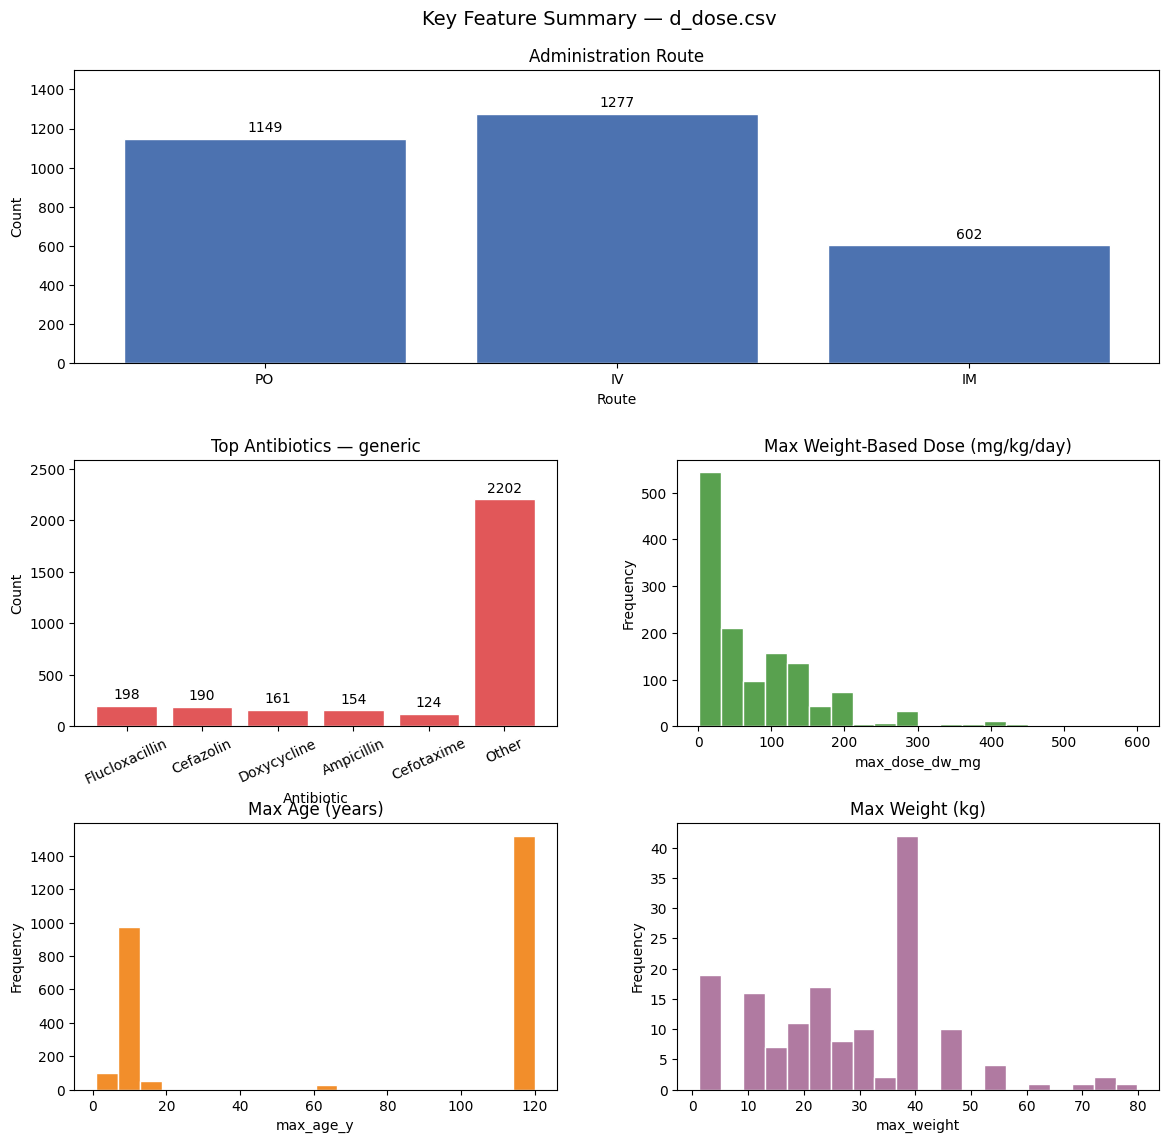

In [30]:
plot_dosage_summary(df_raw_d_dose, "d_dose", "Key Feature Summary — d_dose.csv")


## s_dose.csv

Standardized dosing regimens. Raw preview first, then one-hot encoding of low-cardinality fields (where applicable), unified summary, and summary plots.


In [31]:
df_raw_s_dose = clean_dataset(load_dataset(DATASETS["s_dose"]))
df_raw_s_dose.head()


s_dose.csv: 288 rows × 20 columns


,generic,min_age_d,max_age_d,min_age_m,max_age_m,min_age_y,max_age_y,min_weight,max_weight,min_dose_dw_mg,max_dose_dw_mg,min_dose_dw_iu,max_dose_dw_iu,limit_mg,limit_iu,min_dose_dd_mg,max_dose_dd_mg,min_dose_dd_UNIT,max_dose_dd_iu,route
0,Amikacin,NaN,NaN,NaN,NaN,12.0,65.0,NaN,NaN,10.0,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IM
1,Amikacin,NaN,NaN,NaN,NaN,12.0,65.0,NaN,NaN,10.0,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IV
2,Amikacin,NaN,NaN,1.0,NaN,NaN,11.0,NaN,NaN,10.0,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IM
3,Amikacin,1.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,10.0,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IM
4,Amikacin,NaN,NaN,1.0,NaN,NaN,11.0,NaN,NaN,10.0,15.0,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,IV


In [32]:
df_s_dose = encode_dataset(df_raw_s_dose, "s_dose")
measurement_levels_s_dose = build_measurement_levels(df_s_dose)
column_overview_s_dose = build_column_overview(df_raw_s_dose, "s_dose")
column_overview_s_dose


Analysis shape: 288 rows × 22 columns


,unique_values,measurement_level
column,,
generic,89,nominal
route,3,nominal


In [33]:
unified_summary_s_dose = build_unified_summary(df_s_dose, measurement_levels_s_dose)
unified_summary_s_dose


C:\Users\tnewman\AppData\Local\Temp\ipykernel_10156\1628918410.py:109: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew": stats.skew(numeric.dropna(), bias=False)
C:\Users\tnewman\AppData\Local\Temp\ipykernel_10156\1628918410.py:109: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew": stats.skew(numeric.dropna(), bias=False)
C:\Users\tnewman\AppData\Local\Temp\ipykernel_10156\1628918410.py:109: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew": stats.skew(numeric.dropna(), bias=False)


,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
generic,str,nominal,288,0,89,NaN,NaN,Gentamicin,NaN,NaN,NaN,NaN,<NA>
min_age_d,float64,ratio,44,244,3,5.136,1.0,1.0,1.00,29.0,28.00,2.107,0
max_age_d,float64,ratio,36,252,2,27.778,29.0,29.0,7.00,29.0,22.00,-4.051,0
min_age_m,float64,ratio,95,193,5,1.916,1.0,1.0,1.00,9.0,8.00,2.478,9
max_age_m,float64,ratio,2,286,2,6.000,6.0,3.0,3.00,9.0,6.00,NaN,0
min_age_y,float64,ratio,149,139,7,11.711,12.0,12.0,1.00,18.0,17.00,-1.473,0
max_age_y,float64,ratio,250,38,6,69.304,120.0,120.0,1.00,120.0,119.00,-0.148,0
min_weight,float64,ratio,16,272,10,45.114,47.1,0.0,0.00,79.6,79.60,-0.494,0
max_weight,float64,ratio,14,274,9,51.484,49.5,39.99,13.55,79.5,65.95,-0.215,0


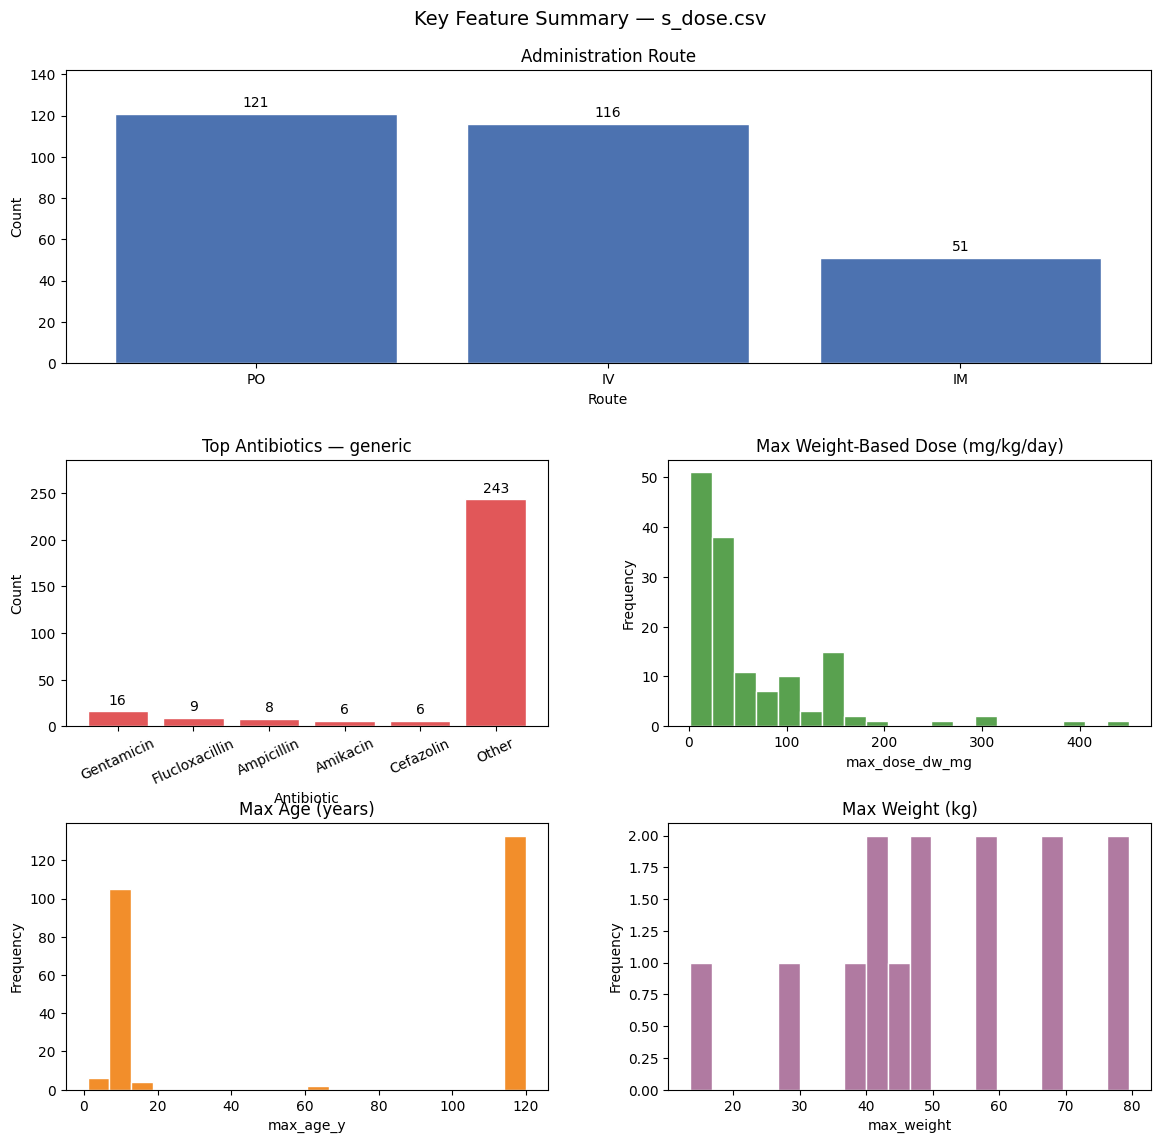

In [34]:
plot_dosage_summary(df_raw_s_dose, "s_dose", "Key Feature Summary — s_dose.csv")


## r_dose.csv

Renal dose adjustments. Raw preview first, then one-hot encoding of low-cardinality fields (where applicable), unified summary, and summary plots.


In [35]:
df_raw_r_dose = clean_dataset(load_dataset(DATASETS["r_dose"]))
df_raw_r_dose.head()


r_dose.csv: 220 rows × 12 columns


,generic,disease,min_weight,max_weight,min_crcl,max_crcl,max_dose_dd_mg,max_dose_dw_mg,max_dose_dd_iu,route,flag
0,Amikacin,NaN,NaN,NaN,70.0,89.0,NaN,12.00,NaN,IV,NaN
1,Amikacin,NaN,NaN,NaN,50.0,69.0,NaN,7.50,NaN,IV,NaN
2,Amikacin,NaN,NaN,NaN,30.0,49.0,NaN,4.00,NaN,IV,NaN
3,Amikacin,NaN,NaN,NaN,30.0,39.0,NaN,4.00,NaN,IV,NaN
4,Amikacin,NaN,NaN,NaN,20.0,29.0,NaN,3.75,NaN,IV,NaN


In [36]:
df_r_dose = encode_dataset(df_raw_r_dose, "r_dose")
measurement_levels_r_dose = build_measurement_levels(df_r_dose)
column_overview_r_dose = build_column_overview(df_raw_r_dose, "r_dose")
column_overview_r_dose


Analysis shape: 220 rows × 14 columns


,unique_values,measurement_level
column,,
generic,73,nominal
disease,2,nominal
route,3,nominal


In [37]:
unified_summary_r_dose = build_unified_summary(df_r_dose, measurement_levels_r_dose)
unified_summary_r_dose


,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
generic,str,nominal,220,0,73,NaN,NaN,Gentamicin,NaN,NaN,NaN,NaN,<NA>
disease,str,nominal,6,214,2,NaN,NaN,Pneumocystis carinii pneumonia,NaN,NaN,NaN,NaN,<NA>
min_weight,float64,ratio,30,190,6,49.900,54.6,0.0,0.0,81.00,81.00,-0.869,0
max_weight,float64,ratio,25,195,5,59.798,59.5,39.5,39.5,80.99,41.49,0.067,0
min_crcl,float64,ratio,198,22,21,16.480,10.0,0.0,0.0,70.00,70.00,1.112,0
max_crcl,float64,ratio,197,23,23,35.853,30.0,29.0,4.0,90.00,86.00,0.863,0
max_dose_dd_mg,float64,ratio,165,55,41,1752.412,500.0,1000.0,0.0,14400.00,14400.00,2.574,18
max_dose_dw_mg,float64,ratio,26,194,11,5.681,4.0,2.5,0.7,25.00,24.30,2.285,1
max_dose_dd_iu,float64,ratio,2,218,2,450000.000,450000.0,300000.0,300000.0,600000.00,300000.00,NaN,0


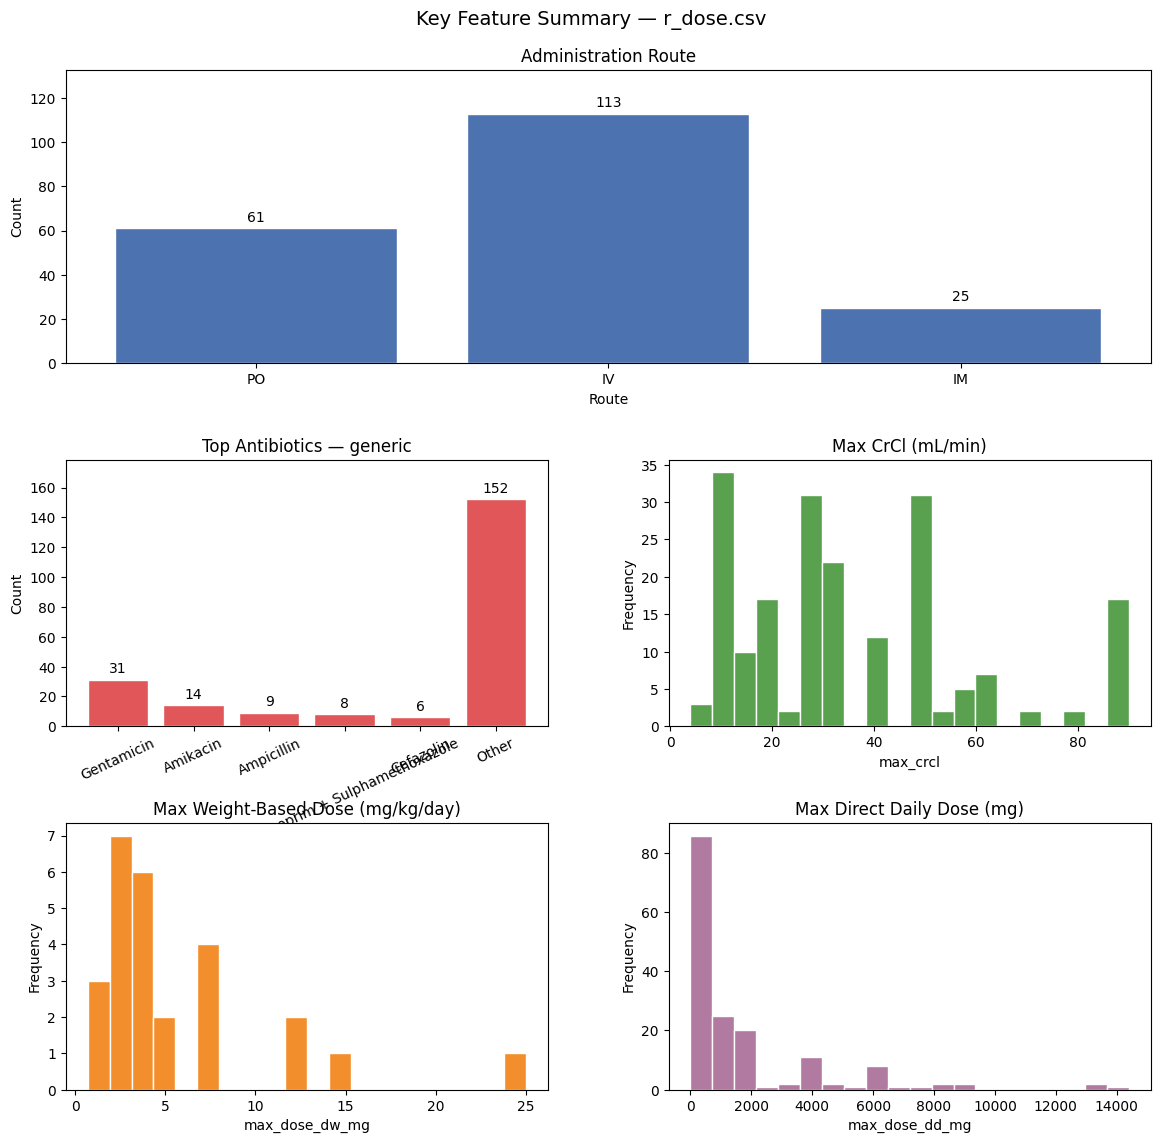

In [38]:
plot_dosage_summary(df_raw_r_dose, "r_dose", "Key Feature Summary — r_dose.csv")


## preg_risk.csv

FDA pregnancy risk classifications. Raw preview first, then one-hot encoding of low-cardinality fields (where applicable), unified summary, and summary plots.


In [39]:
df_raw_preg_risk = clean_dataset(load_dataset(DATASETS["preg_risk"]))
df_raw_preg_risk.head()


preg_risk.csv: 98 rows × 2 columns


,generic,r_category
0,Amikacin,D
1,Amikacin,D
2,Amoxicillin,B
3,Amoxicillin + Clavulanic Acid,B
4,Amphotericin B,B


In [40]:
df_preg_risk = encode_dataset(df_raw_preg_risk, "preg_risk")
measurement_levels_preg_risk = build_measurement_levels(df_preg_risk)
column_overview_preg_risk = build_column_overview(df_raw_preg_risk, "preg_risk")
column_overview_preg_risk


Analysis shape: 98 rows × 2 columns


,unique_values,measurement_level
column,,
generic,97,nominal
r_category,5,ordinal


In [41]:
unified_summary_preg_risk = build_unified_summary(df_preg_risk, measurement_levels_preg_risk)
unified_summary_preg_risk


,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
generic,str,nominal,98,0,97,NaN,NaN,Amikacin,NaN,NaN,NaN,NaN,<NA>
r_category_ordinal,float64,ordinal,91,7,3,1.582,1.0,1.0,1.0,3.0,2.0,0.818,0


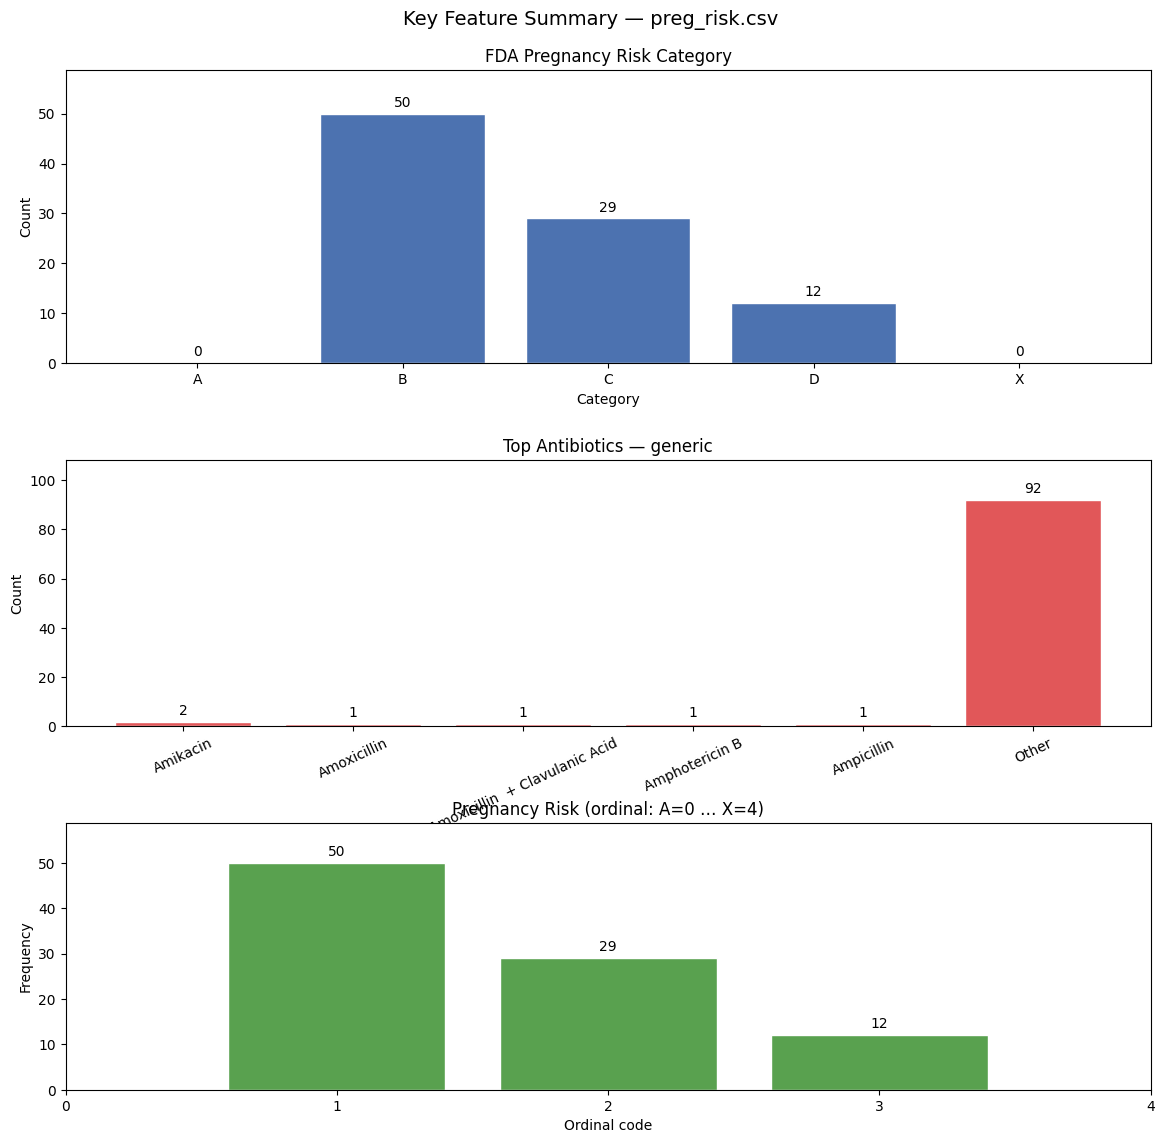

In [42]:
plot_dosage_summary(df_raw_preg_risk, "preg_risk", "Key Feature Summary — preg_risk.csv")


## generic_disease_map.csv

Antibiotic–disease lookup. Raw preview first, then one-hot encoding of low-cardinality fields (where applicable), unified summary, and summary plots.


In [43]:
df_raw_generic_disease_map = clean_dataset(load_dataset(DATASETS["generic_disease_map"]))
df_raw_generic_disease_map.head()


generic_disease_map.csv: 1,066 rows × 2 columns


,generic,disease
0,Amikacin,Bacteremia
1,Amikacin,Bacterial Infection
2,Amikacin,Bone and Joint Infection
3,Amikacin,Intraabdominal Infection
4,Amikacin,Meningitis


In [ ]:
df_generic_disease_map = encode_dataset(df_raw_generic_disease_map, "generic_disease_map")
measurement_levels_generic_disease_map = build_measurement_levels(df_generic_disease_map)
column_overview_generic_disease_map = build_column_overview(df_raw_generic_disease_map, "generic_disease_map")
column_overview_generic_disease_map


Analysis shape: 1,066 rows × 2 columns


,unique_values,measurement_level
column,,
generic,97,nominal
disease,267,nominal


In [45]:
unified_summary_generic_disease_map = build_unified_summary(df_generic_disease_map, measurement_levels_generic_disease_map)
unified_summary_generic_disease_map


,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
generic,str,nominal,1066,0,97,NaN,NaN,Doxycycline,NaN,NaN,NaN,NaN,<NA>
disease,str,nominal,1065,1,267,NaN,NaN,Pneumonia,NaN,NaN,NaN,NaN,<NA>


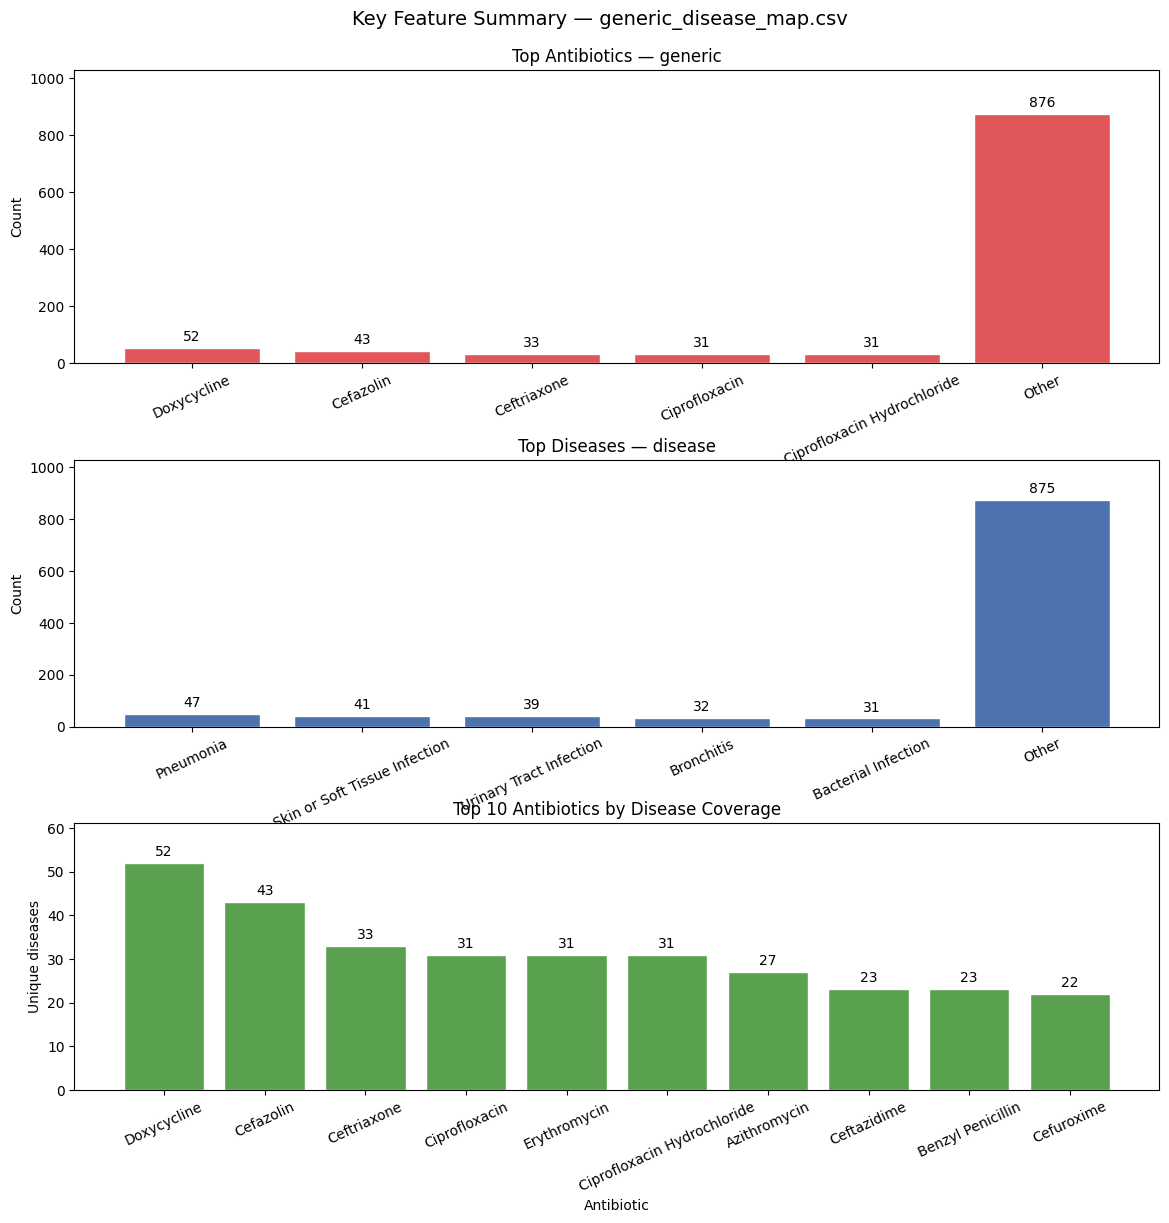

In [46]:
plot_dosage_summary(df_raw_generic_disease_map, "generic_disease_map", "Key Feature Summary — generic_disease_map.csv")
